# Strength evolution animation notebook

This notebook is a cleaned, notebook-style replacement for the older
`animate_strength_evolution.py` and `animate_strength_evolution_two_subplots.py`
analysis scripts.

It is designed for **debugging and analysis** of a trained strength + $lpha_D$
emulator. The notebook:

- loads a saved training run,
- reconstructs emulator predictions on the dataset,
- computes relative $lpha_D$ error across the grid,
- animates a 1D sweep through parameter space,
- optionally shows how the eigenvalues evolve during that sweep.

The notebook assumes a **2-parameter dataset** for the grid visualization.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

import numpy as np
import tensorflow as tf

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import LogNorm
import matplotlib.patches as patches

import helper_gpt

plt.rcParams.update({"font.size": 14})

## User configuration

Update these values for the run and sweep you want to inspect.

In [2]:
# -----------------------------------------------------------------------------
# User configuration
# -----------------------------------------------------------------------------
RUN_DIR = Path("runs_em1")
BEST_PARAMS_FILE = RUN_DIR / "best_params_global.txt"
RUN_SUMMARY_FILE = RUN_DIR / "run_summary.json"

STRENGTH_DIR = "../dipoles_data_all/total_strength/"
ALPHAD_DIR = "../dipoles_data_all/total_alphaD/"
STRENGTH_REGEX = r"strength_(?P<p2>[0-9.]+)_(?P<p1>[0-9.]+)\.out"
ALPHAD_REGEX = None
FILTER_RANGES = None
CENTRAL_POINT = None

RETAIN = 0.5                 # centered fraction of eigenmodes to keep
SWEEP_MODE = "beta"          # "alpha" or "beta"
FIXED_VALUE = 1.1            # if SWEEP_MODE == "beta", fix alpha = FIXED_VALUE
SHOW_EIGENVALUE_PANEL = True

STRENGTH_XLIM = (0.0, 40.0)
STRENGTH_YLIM = (0.0, 20.0)
EIGEN_YLIM = (-50.0, 100.0)

SAVE_ANIMATION = False
OUTPUT_MP4 = RUN_DIR / f"strength_evolution_{SWEEP_MODE}_fixed_{FIXED_VALUE:.4f}.mp4"
FPS = 1.3
INTERVAL_MS = 700

## Load the run and dataset

In [3]:
with open(RUN_SUMMARY_FILE, "r") as f:
    run_summary = json.load(f)

config_dict = run_summary["config"]
config = helper_gpt.AnsatzConfig(
    n=int(config_dict["n"]),
    n_params=int(config_dict["n_params"]),
    ansatz=config_dict["ansatz"],
    width_model=config_dict["width_model"],
    use_vector_terms=bool(config_dict["use_vector_terms"]),
)

params = np.loadtxt(BEST_PARAMS_FILE).astype(np.float32)
params_tf = tf.convert_to_tensor(params, dtype=tf.float32)

dataset = helper_gpt.load_dataset(
    strength_dir=STRENGTH_DIR,
    alphaD_dir=ALPHAD_DIR,
    strength_regex=STRENGTH_REGEX,
    alphaD_regex=ALPHAD_REGEX,
    filter_ranges=FILTER_RANGES,
    central_point=CENTRAL_POINT,
)

if dataset.param_values.shape[1] != 2:
    raise ValueError(
        "This notebook expects a 2-parameter dataset for the grid plot. "
        f"Found n_params={dataset.param_values.shape[1]}."
    )

omega_ref = dataset.strengths[0][:, 0].astype(np.float32)
for idx, s in enumerate(dataset.strengths[1:], start=1):
    if s.shape[0] != len(omega_ref) or not np.allclose(s[:, 0], omega_ref):
        raise ValueError(f"Strength files must share the same omega grid; mismatch at index {idx}.")

param_names = dataset.param_names
param_values = dataset.param_values.astype(np.float32)
central_point = dataset.central_point.astype(np.float32)

print("Loaded run from:", RUN_DIR)
print("Config:", helper_gpt.summarize_config(config))
print("Parameter names:", param_names)
print("Central point:", central_point)
print("Samples:", len(dataset.strengths))

Loaded run from: runs_em1
Config: {'n': 10, 'n_params': 2, 'ansatz': 'linear_exp', 'width_model': 'affine', 'use_vector_terms': True, 'n_basis': 4, 'n_upper': 55, 'n_trainable': 266}
Parameter names: ['p1', 'p2']
Central point: [1.1  2.75]
Samples: 225


## Helper functions

In [4]:
def keep_centered_modes(eigenvalues: tf.Tensor, eigenvectors: tf.Tensor, retain: float):
    """Keep the centered block of eigenmodes, matching the training loss."""
    n_i = int(eigenvalues.shape[0])
    k_keep = int(round(float(retain) * n_i))
    k_keep = max(1, min(k_keep, n_i))
    left = (n_i - k_keep) // 2
    right = left + k_keep
    return eigenvalues[left:right], eigenvectors[:, left:right], left, right


def find_dataset_index(point: np.ndarray) -> int:
    matches = np.where(np.all(np.isclose(param_values, point[None, :]), axis=1))[0]
    if len(matches) != 1:
        raise ValueError(f"Expected exactly one dataset point matching {point}, found {len(matches)}.")
    return int(matches[0])


def evaluate_strength_point(point: np.ndarray):
    """Evaluate the trained emulator at a single parameter point."""
    point = np.asarray(point, dtype=np.float32).reshape(1, -1)

    M_batch, v_batch, eta_batch, _ = helper_gpt.build_model_matrices_and_vectors(
        params=params_tf,
        config=config,
        param_values=tf.convert_to_tensor(point, dtype=tf.float32),
        central_point=tf.convert_to_tensor(central_point, dtype=tf.float32),
    )

    M = M_batch[0]
    v = v_batch[0]
    eta = float(eta_batch[0].numpy())

    eigenvalues_full, eigenvectors_full = tf.linalg.eigh(M)
    eigenvalues_kept, eigenvectors_kept, left, right = keep_centered_modes(
        eigenvalues_full, eigenvectors_full, RETAIN
    )

    proj = tf.linalg.matvec(tf.transpose(eigenvectors_kept), v)
    B_kept = tf.square(proj)
    mask = tf.cast(eigenvalues_kept > 1.0, dtype=tf.float32)
    B_masked = B_kept * mask

    omega_tf = tf.convert_to_tensor(omega_ref, dtype=tf.float32)
    lor = helper_gpt.give_me_Lorentzian(
        omega_tf,
        eigenvalues_kept,
        B_masked,
        tf.constant(eta, dtype=tf.float32),
    )

    alphaD_pred = helper_gpt.calculate_alphaD(eigenvalues_kept, B_kept)

    return {
        "eigenvalues_full": eigenvalues_full.numpy(),
        "eigenvalues_kept": eigenvalues_kept.numpy(),
        "B_kept": B_kept.numpy(),
        "B_masked": B_masked.numpy(),
        "eta": eta,
        "strength_pred": lor.numpy(),
        "alphaD_pred": float(alphaD_pred.numpy()),
        "left": left,
        "right": right,
    }


def build_sweep_points(mode: str, fixed_value: float):
    if mode not in {"alpha", "beta"}:
        raise ValueError(f"Unknown sweep mode {mode!r}.")

    if mode == "alpha":
        fixed_axis = 1
        sweep_axis = 0
    else:
        fixed_axis = 0
        sweep_axis = 1

    mask = np.isclose(param_values[:, fixed_axis], float(fixed_value))
    pts = param_values[mask]
    if len(pts) == 0:
        raise ValueError(
            f"No dataset points found for mode={mode!r} with fixed_value={fixed_value}."
        )

    order = np.argsort(pts[:, sweep_axis])
    return pts[order]

## Precompute emulator predictions over the full dataset

Precomputing keeps the animation responsive and avoids repeated tensor work in every frame.

In [5]:
records = []
for i, point in enumerate(param_values):
    result = evaluate_strength_point(point)
    alphaD_true = float(dataset.alphaD_values[i])
    alphaD_rel_error = abs(result["alphaD_pred"] - alphaD_true) / max(abs(alphaD_true), 1.0e-8)

    records.append({
        "index": i,
        "point": point.copy(),
        "strength_true": dataset.strengths[i][:, 1].astype(np.float32),
        "strength_pred": result["strength_pred"],
        "alphaD_true": alphaD_true,
        "alphaD_pred": result["alphaD_pred"],
        "alphaD_rel_error": alphaD_rel_error,
        "eigenvalues_full": result["eigenvalues_full"],
        "eigenvalues_kept": result["eigenvalues_kept"],
        "B_masked": result["B_masked"],
    })

alphaD_errors = np.array([r["alphaD_rel_error"] for r in records])
print("Mean alphaD relative error:", alphaD_errors.mean())
print("Max  alphaD relative error:", alphaD_errors.max())

Mean alphaD relative error: 0.0004419159267128743
Max  alphaD relative error: 0.0021002173167862397


## Build the sweep

In [6]:
sweep_points = build_sweep_points(SWEEP_MODE, FIXED_VALUE)
sweep_indices = [find_dataset_index(point) for point in sweep_points]

sweep_axis = 0 if SWEEP_MODE == "alpha" else 1
fixed_axis = 1 - sweep_axis
sweep_param_name = param_names[sweep_axis]
fixed_param_name = param_names[fixed_axis]

param_min = float(np.min(sweep_points[:, sweep_axis]))
param_max = float(np.max(sweep_points[:, sweep_axis]))

print(f"Sweep mode: {SWEEP_MODE}")
print(f"Fixed {fixed_param_name} = {FIXED_VALUE}")
print(f"Frames: {len(sweep_indices)}")

Sweep mode: beta
Fixed p1 = 1.1
Frames: 15


## Optional static preview before animating

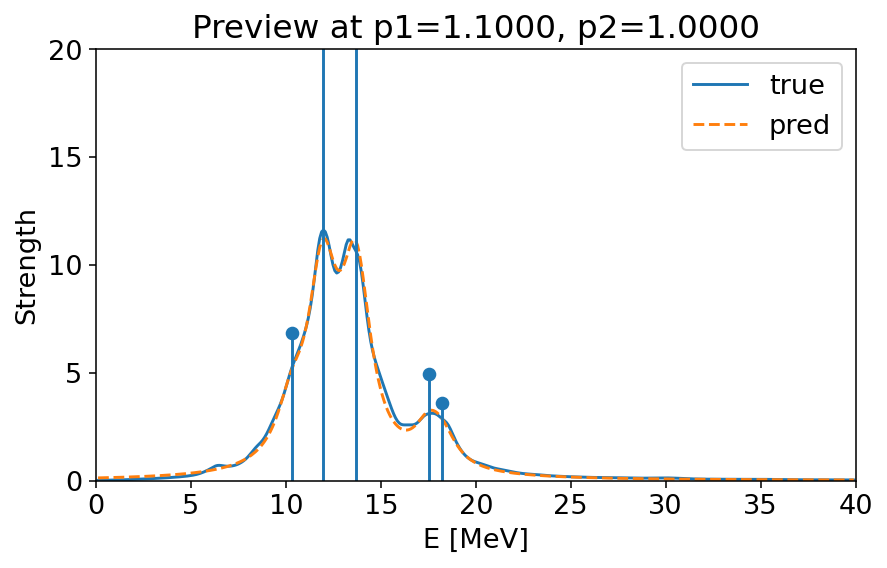

In [7]:
preview_idx = sweep_indices[0]
preview = records[preview_idx]

fig, ax = plt.subplots(figsize=(7, 4), dpi=140)
ax.plot(omega_ref, preview["strength_true"], label="true")
ax.plot(omega_ref, preview["strength_pred"], "--", label="pred")
ax.stem(preview["eigenvalues_kept"], preview["B_masked"], basefmt=" ")
ax.set_xlabel("E [MeV]")
ax.set_ylabel("Strength")
ax.set_title(
    f"Preview at {param_names[0]}={preview['point'][0]:.4f}, {param_names[1]}={preview['point'][1]:.4f}"
)
ax.set_xlim(*STRENGTH_XLIM)
ax.set_ylim(*STRENGTH_YLIM)
ax.legend()
plt.show()

## Create the animation

In [8]:
# Scatter-grid inputs
x_all = param_values[:, 0]
y_all = param_values[:, 1]
train_x = run_summary.get("train_param_values")

# Use all loaded samples to define the visible dataset region.
alpha_min = float(np.min(x_all))
alpha_max = float(np.max(x_all))
beta_min = float(np.min(y_all))
beta_max = float(np.max(y_all))

n_rows = 3 if SHOW_EIGENVALUE_PANEL else 2
height_ratios = [1, 1, 1] if SHOW_EIGENVALUE_PANEL else [1, 1]

fig, axes = plt.subplots(
    n_rows,
    1,
    figsize=(8, 14 if SHOW_EIGENVALUE_PANEL else 10),
    dpi=150,
    gridspec_kw={"height_ratios": height_ratios},
)

if SHOW_EIGENVALUE_PANEL:
    ax_strength, ax_grid, ax_eigs = axes
else:
    ax_strength, ax_grid = axes
    ax_eigs = None

fig.suptitle(f"Strength evolution diagnostic (n = {config.n})", fontsize=16, y=0.97)
fig.subplots_adjust(top=0.93, hspace=0.38)

# Strength panel
ax_strength.set_xlim(*STRENGTH_XLIM)
ax_strength.set_ylim(*STRENGTH_YLIM)
ax_strength.set_xlabel("E [MeV]")
ax_strength.set_ylabel("Strength")

# Grid panel
sc = ax_grid.scatter(
    x_all,
    y_all,
    c=alphaD_errors,
    cmap="Spectral",
    norm=LogNorm(vmin=max(alphaD_errors.min(), 1e-8), vmax=alphaD_errors.max()),
    marker="s",
)
marker_x, = ax_grid.plot([], [], "kX", markersize=10, markeredgewidth=2)

ax_grid.set_xlabel(fr"${param_names[0]}$")
ax_grid.set_ylabel(fr"${param_names[1]}$")
ax_grid.set_xlim(alpha_min - 0.1, alpha_max + 0.1)
ax_grid.set_ylim(beta_min - 0.1, beta_max + 0.1)
fig.colorbar(sc, ax=ax_grid, label=r"Relative error on $lpha_D$")

# Dataset bounding box
rect = patches.Rectangle(
    (alpha_min, beta_min),
    alpha_max - alpha_min,
    beta_max - beta_min,
    linewidth=1.5,
    edgecolor="black",
    facecolor="none",
)
ax_grid.add_patch(rect)

# Eigenvalue history storage
param_vals_for_eigs = []
eigenvalues_history_full = []
eigenvalues_history_kept = []


def init():
    marker_x.set_data([], [])
    return (marker_x,)


def animate(frame_idx: int):
    dataset_idx = sweep_indices[frame_idx]
    record = records[dataset_idx]
    point = record["point"]

    # Strength panel
    ax_strength.cla()
    ax_strength.set_xlim(*STRENGTH_XLIM)
    ax_strength.set_ylim(*STRENGTH_YLIM)
    ax_strength.set_xlabel("E [MeV]")
    ax_strength.set_ylabel("Strength")
    ax_strength.set_title(
        fr"${param_names[0]} = {point[0]:.4f},\ {param_names[1]} = {point[1]:.4f}$"
    )
    ax_strength.plot(omega_ref, record["strength_true"], "k-", label="Original")
    ax_strength.plot(omega_ref, record["strength_pred"], "r--", label="PMM-Lorentzian")
    ax_strength.stem(
        record["eigenvalues_kept"],
        record["B_masked"],
        basefmt=" ",
        markerfmt="go",
        linefmt="g-",
    )
    ax_strength.legend()

    # Grid panel marker
    marker_x.set_data([float(point[0])], [float(point[1])])

    # Eigenvalue panel
    if ax_eigs is not None:
        param_val = float(point[sweep_axis])
        param_vals_for_eigs.append(param_val)
        eigenvalues_history_full.append(record["eigenvalues_full"])
        eigenvalues_history_kept.append(record["eigenvalues_kept"])

        param_array = np.array(param_vals_for_eigs)
        eig_full = np.array(eigenvalues_history_full)
        eig_kept = np.array(eigenvalues_history_kept)

        ax_eigs.cla()
        ax_eigs.set_xlabel(fr"${sweep_param_name}$")
        ax_eigs.set_ylabel("Eigenvalues")
        ax_eigs.set_xlim(param_min, param_max)
        ax_eigs.set_ylim(*EIGEN_YLIM)
        ax_eigs.grid(True)
        ax_eigs.set_title("Eigenvalue evolution")

        for k in range(eig_full.shape[1]):
            ax_eigs.plot(param_array, eig_full[:, k], "-", color="gray", linewidth=2, alpha=0.9)
        for k in range(eig_kept.shape[1]):
            ax_eigs.plot(param_array, eig_kept[:, k], "o-", markersize=4)

    return (marker_x,)


ani = animation.FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=len(sweep_indices),
    interval=INTERVAL_MS,
    repeat=False,
    blit=False,
)

plt.close(fig)
ani

## Optional save

Set `SAVE_ANIMATION = True` in the configuration cell before running this cell.

In [9]:
if SAVE_ANIMATION:
    OUTPUT_MP4.parent.mkdir(parents=True, exist_ok=True)
    ani.save(OUTPUT_MP4, writer="ffmpeg", fps=FPS)
    print(f"Saved animation to {OUTPUT_MP4}")
else:
    print("SAVE_ANIMATION is False; animation was not written to disk.")

SAVE_ANIMATION is False; animation was not written to disk.


## Notes for future cleanup

Good next improvements, if you want this notebook to become a standard analysis template:

1. Add a cell that reads a **specific restart directory** instead of only the global-best parameters.
2. Add a **dropdown widget** for `SWEEP_MODE` and `FIXED_VALUE`.
3. For datasets with more than two parameters, replace the grid panel with a **projection** or a **table of fixed coordinates**.
4. If you create more debugging notebooks, keep the same top-level structure:
   **configuration → data loading → helper functions → precompute → visualization**.